In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [4]:
import pandas as pd

from config import BINANCE_PATH, RESULTS_PATH

r = pd.read_parquet(BINANCE_PATH / 'as_results.parquet')

In [5]:
import params.misc

f, decay_point = params.misc.compute_tau(r)

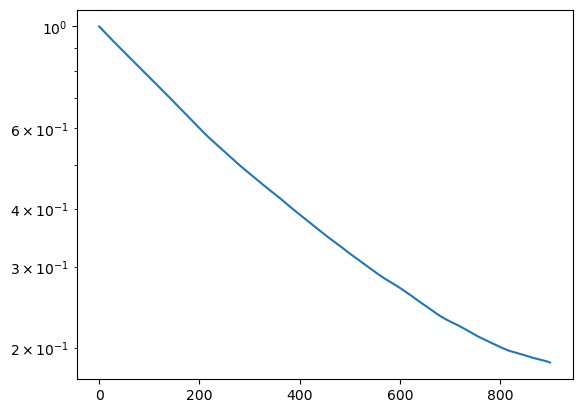

In [6]:
import matplotlib.pyplot as plt

# acf = e^(-lag / theta)
# ln(acf) = -lag / theta

plt.semilogy(f[:900])

In [7]:
print(f'decay point: {decay_point}')

decay point: 429


In [8]:
mid = pd.read_parquet(BINANCE_PATH / 'mid_1s.parquet')

qlikes = params.misc.sweep_half_life(mid)
print(qlikes)

zeros dropped: mid_price    199
dtype: int64
zeros dropped: mid_price    199
dtype: int64
zeros dropped: mid_price    199
dtype: int64
zeros dropped: mid_price    199
dtype: int64
{'5min': mid_price    1.615362
dtype: float64, '10min': mid_price    1.596406
dtype: float64, '15min': mid_price    1.595828
dtype: float64, '30min': mid_price    1.613039
dtype: float64}


In [9]:
res, rows = params.misc.sweep_gamma()
df = pd.DataFrame(rows)
df['markout_per_fill'] = df['inv_pnl'] / (df['bid_fills'] + df['ask_fills'])
df.to_csv(RESULTS_PATH / 'gamma_sweep.csv', index = False)

In [10]:
df

,gamma,strategy,terminal_wealth,spread_pnl,inv_pnl,bid_fills,ask_fills,mean_spread,q_std,mean_abs_q,max_abs_q,markout_per_fill
0,0.000100,g=1.0e-04,-7145.041158,4549.686842,-11694.7280,67116,67111,6.146837,0.181282,0.141143,0.87,-0.087126
1,0.000193,g=1.9e-04,-6054.491516,4929.232484,-10983.7240,57312,57307,7.907268,0.113715,0.087746,0.71,-0.095828
2,0.000373,g=3.7e-04,-4228.138972,4791.333528,-9019.4725,42656,42655,11.306128,0.075262,0.058051,0.47,-0.105725
3,0.000720,g=7.2e-04,-2226.715424,3781.037076,-6007.7525,25531,25533,17.868302,0.058638,0.045683,0.31,-0.117651
4,0.001389,g=1.4e-03,-1136.330310,2284.113190,-3420.4435,11208,11215,30.537881,0.054622,0.043198,0.23,-0.152542
5,0.002683,g=2.7e-03,-168.879879,1008.182621,-1177.0625,3321,3328,54.999023,0.054282,0.043571,0.22,-0.177029
6,0.005179,g=5.2e-03,12.164343,326.540843,-314.3765,654,663,102.226155,0.048082,0.040845,0.13,-0.238707
7,0.010000,g=1.0e-02,-6.937222,67.866778,-74.8040,84,88,193.407691,0.027563,0.025826,0.08,-0.434907
